In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [3]:
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 9,
    'font.family': 'DejaVu Sans',
})
PALETTE = {'default': '#E53935', 'non_default': '#1E88E5'}
TARGET_COL = 'default payment next month'

In [4]:
df = pd.read_csv("C:/Users/thanh/Documents/HPC Final Term/credit_risk_predictor/data/raw/default_of_credit_card_clients.csv")
df.columns = df.columns.str.strip()
df = df.drop(columns=['ID'])
df = df.rename(columns={TARGET_COL: 'DEFAULT'})

**Phần 1: Thống kê mô tả**

In [5]:
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Missing values: {df.isnull().sum().sum()}")

Dataset: 30,000 rows × 24 cols
Missing values: 0


In [6]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [7]:
BILL_COLS = [f'BILL_AMT{i}' for i in range(1, 6)]

In [8]:
for col in BILL_COLS:
    n_neg = (df[col] < 0).sum()
    min_val = df[col].min()
    print(f"  {col}: {n_neg:>4} giá trị âm, min = {min_val:>10,.0f} NT$  "
          f"{'← trả thừa, valid' if n_neg > 0 else ''}")
print("==> Giá trị âm trong BILL_AMT = khách hàng đã thanh toán thừa số dư")

  BILL_AMT1:  590 giá trị âm, min =   -165,580 NT$  ← trả thừa, valid
  BILL_AMT2:  669 giá trị âm, min =    -69,777 NT$  ← trả thừa, valid
  BILL_AMT3:  655 giá trị âm, min =   -157,264 NT$  ← trả thừa, valid
  BILL_AMT4:  675 giá trị âm, min =   -170,000 NT$  ← trả thừa, valid
  BILL_AMT5:  655 giá trị âm, min =    -81,334 NT$  ← trả thừa, valid
==> Giá trị âm trong BILL_AMT = khách hàng đã thanh toán thừa số dư


In [9]:
num_cols = ['LIMIT_BAL', 'AGE'] + [f'BILL_AMT{i}' for i in range(1, 7)] + [f'PAY_AMT{i}' for i in range(1, 7)]
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0'] + [f'PAY_{i}' for i in range(2, 7)]

SEABORN_PALETTE = {0: PALETTE['non_default'], 1: PALETTE['default']}

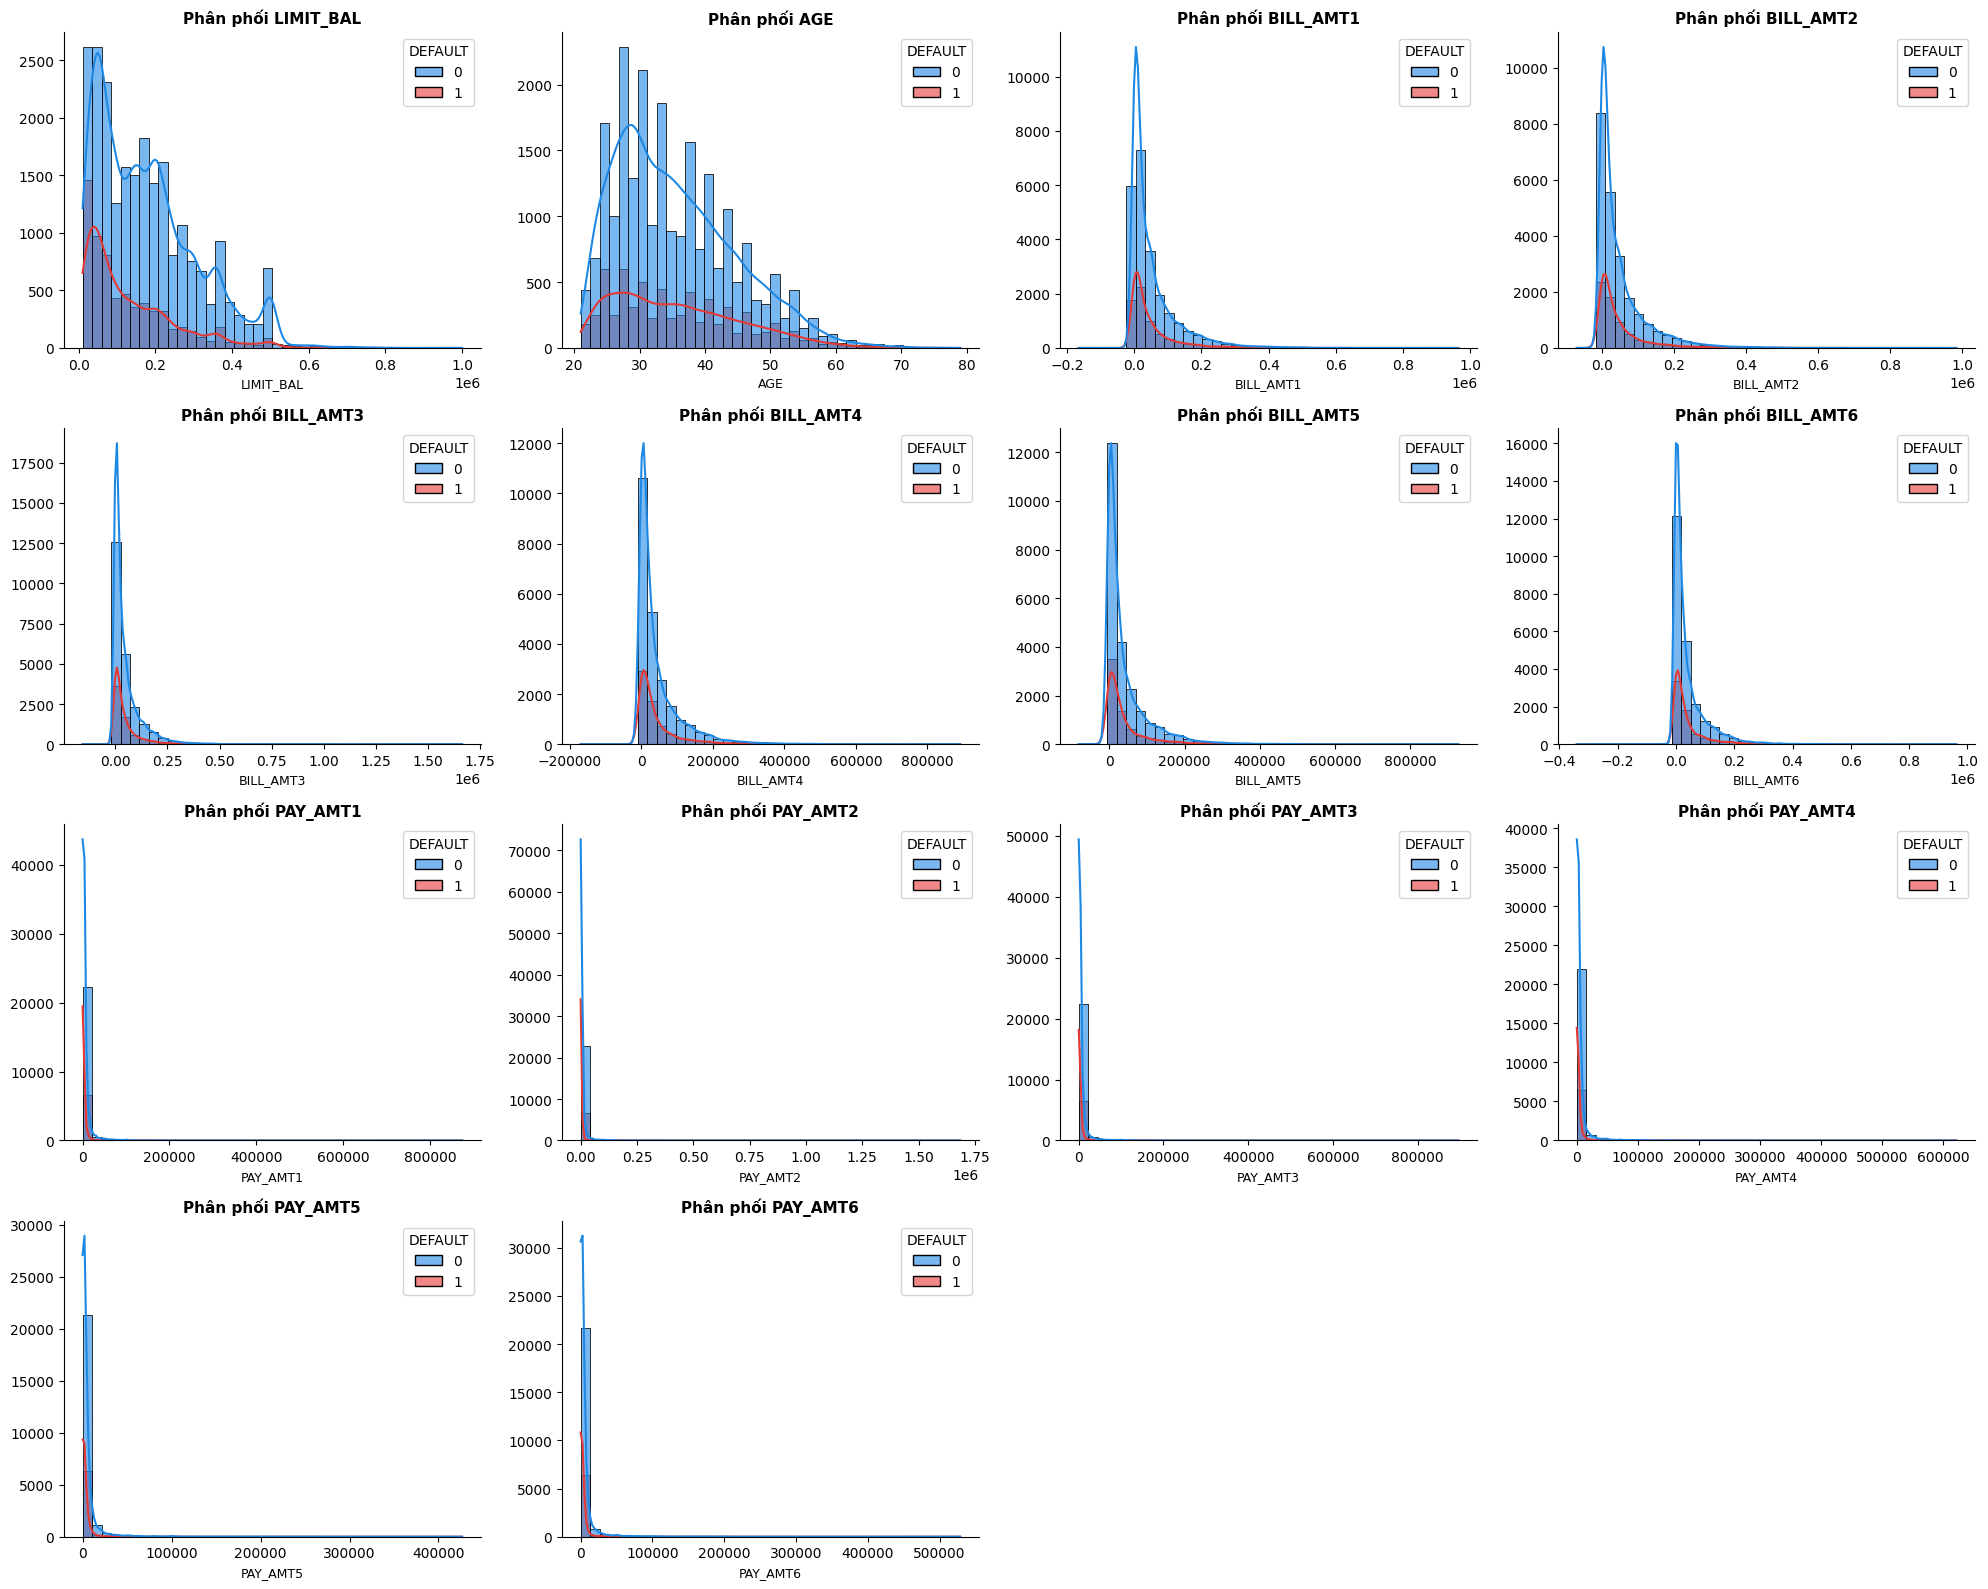

In [10]:
n_cols_num = 4
n_rows_num = int(np.ceil(len(num_cols) / n_cols_num))

fig1, axes1 = plt.subplots(n_rows_num, n_cols_num, figsize=(20, 4 * n_rows_num))
axes1 = axes1.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='DEFAULT', bins=40, kde=True,
                 palette=SEABORN_PALETTE, ax=axes1[i], alpha=0.6)
    axes1[i].set_title(f'Phân phối {col}')
    axes1[i].set_ylabel('')

for j in range(i + 1, len(axes1)):
    fig1.delaxes(axes1[j])

plt.tight_layout()
plt.show()

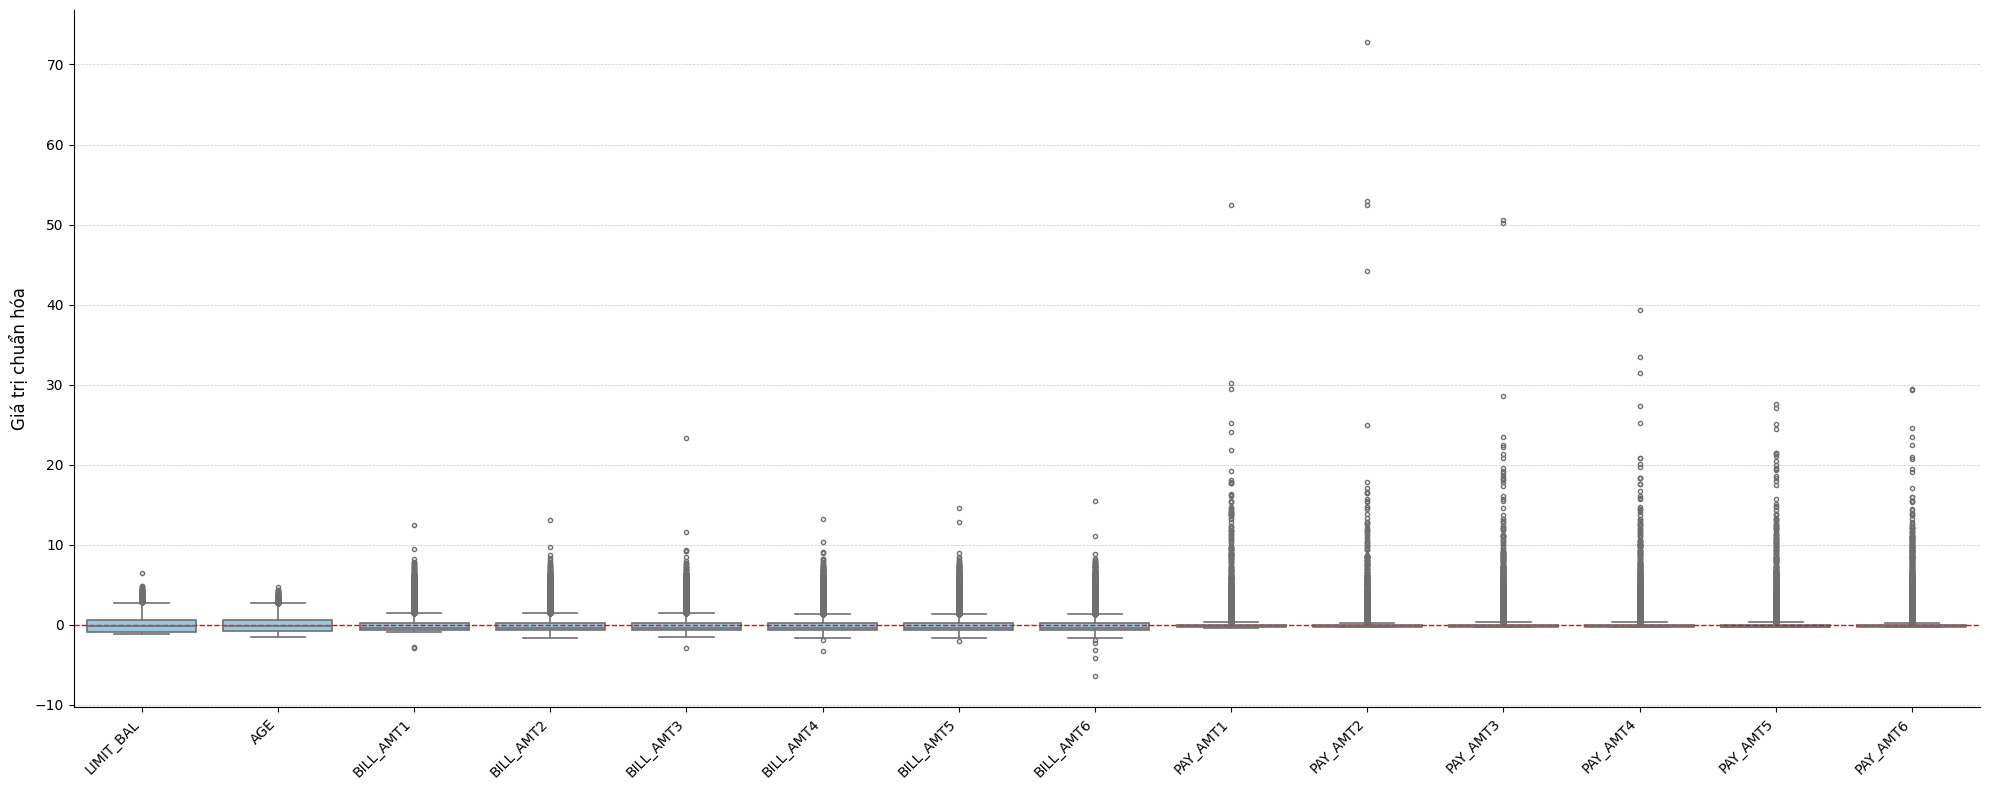

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled_num = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols)

df_melted = pd.melt(df_scaled_num, value_vars=num_cols)

plt.figure(figsize=(20, 8))
sns.boxplot(data=df_melted, x='variable', y='value', color='skyblue',
            linewidth=1.2, fliersize=3)

plt.xlabel('')
plt.ylabel('Giá trị chuẩn hóa', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

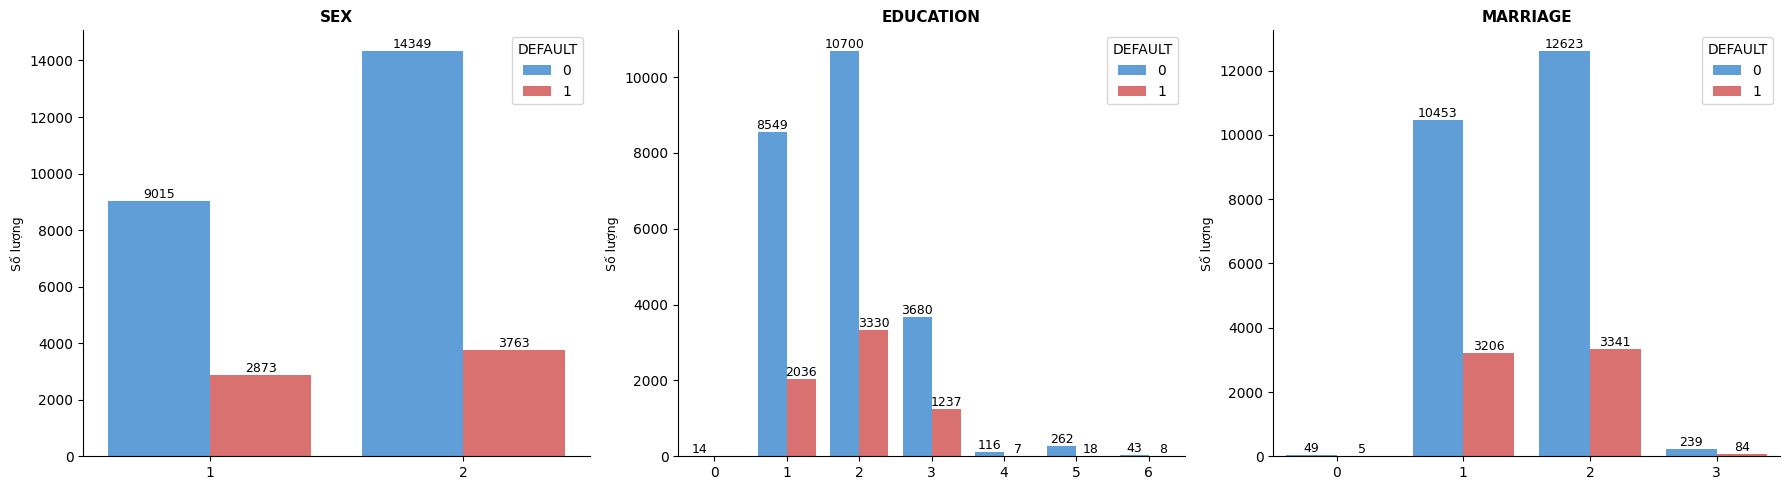

In [12]:
target_cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

n_cols_cat = 3
n_rows_cat = int(np.ceil(len(target_cat_cols) / n_cols_cat))

fig3, axes3 = plt.subplots(n_rows_cat, n_cols_cat, figsize=(18, 5 * n_rows_cat))
axes3 = np.array(axes3).flatten()

for i, col in enumerate(target_cat_cols):
    sns.countplot(data=df, x=col, hue='DEFAULT', palette=SEABORN_PALETTE, ax=axes3[i], alpha=0.8)
    axes3[i].set_title(f'{col}', fontweight='bold')
    axes3[i].set_ylabel('Số lượng')
    axes3[i].set_xlabel('')

    for p in axes3[i].patches:
        height = p.get_height()
        if height > 0:
            axes3[i].annotate(f'{int(height)}',
                              (p.get_x() + p.get_width() / 2., height),
                              ha='center', va='bottom', fontsize=9)

for j in range(i + 1, len(axes3)):
    fig3.delaxes(axes3[j])

plt.tight_layout()
plt.show()

**Phần 2: Phân tích biến mục tiêu**

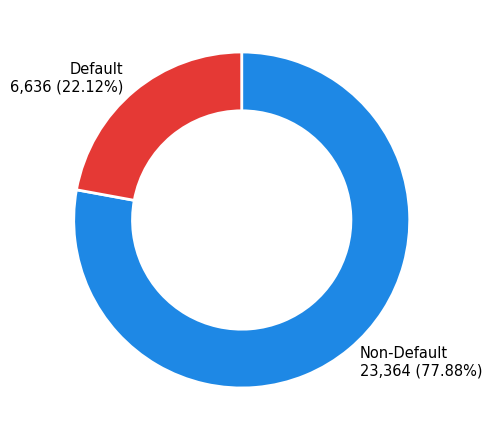

In [13]:
counts     = df['DEFAULT'].value_counts()
pct_default     = counts[1] / len(df) * 100
pct_non_default = counts[0] / len(df) * 100

fig, ax = plt.subplots(figsize=(8.5, 4.5))

labels = [
    f'Non-Default\n{counts[0]:,} ({pct_non_default:.2f}%)',
    f'Default\n{counts[1]:,} ({pct_default:.2f}%)'
]

wedges, texts = ax.pie(
    [counts[0], counts[1]],
    labels=labels,
    colors=[PALETTE['non_default'], PALETTE['default']],
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.35, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=10.5)
)

plt.tight_layout()
plt.show()

**Phần 3: Phân Tích Đa Biến & Hiện Tượng Đa Cộng Tuyến**

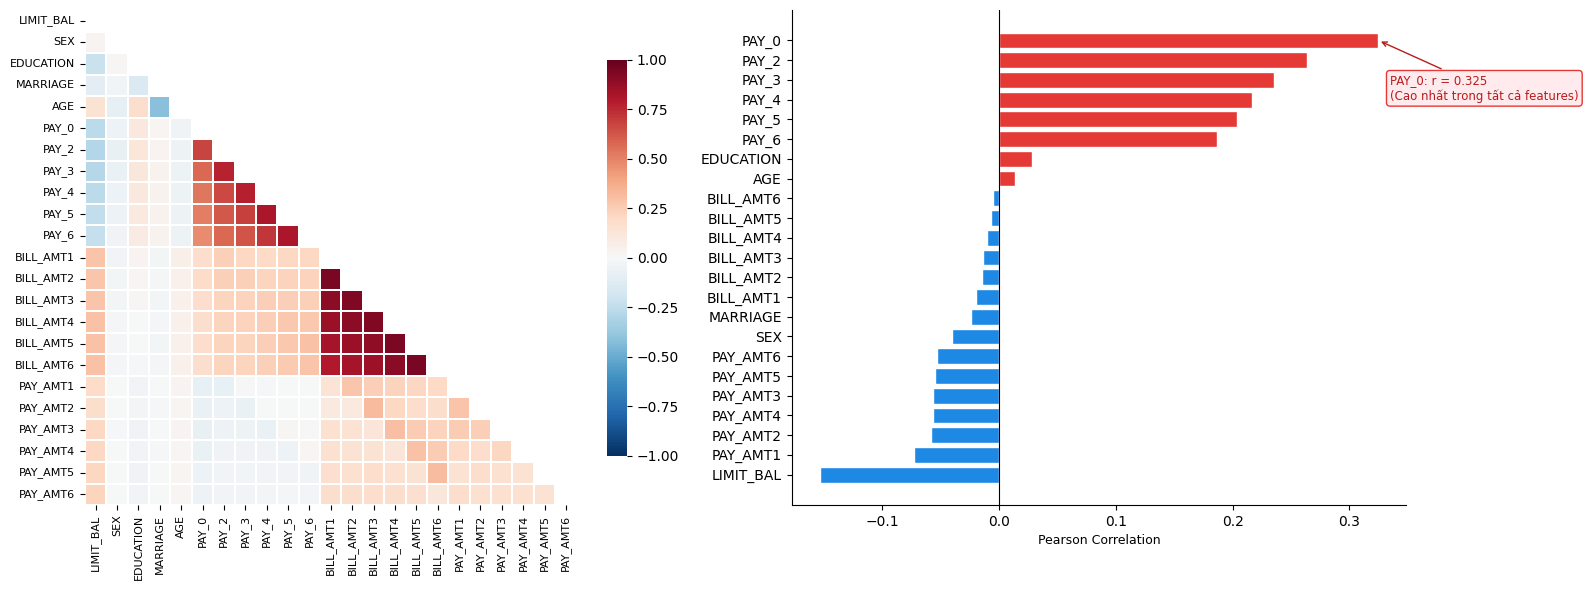

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr = df.drop(columns=['DEFAULT']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=axes[0],
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=False, linewidths=0.3,
    cbar_kws={'shrink': 0.8}
)

axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

target_corr = df.corr()['DEFAULT'].drop('DEFAULT').sort_values()
colors = [PALETTE['default'] if v > 0 else PALETTE['non_default']
          for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson Correlation')

pay0_corr = target_corr['PAY_0']
axes[1].annotate(
    f'PAY_0: r = {pay0_corr:.3f}\n(Cao nhất trong tất cả features)',
    xy=(pay0_corr, list(target_corr.index).index('PAY_0')),
    xytext=(pay0_corr + 0.01, list(target_corr.index).index('PAY_0') - 3),
    fontsize=8.5, color='#B71C1C',
    arrowprops=dict(arrowstyle='->', color='#B71C1C'),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#E53935')
)

plt.tight_layout()
plt.show()

**Phần 4: Phân Tích Nhân khẩu học Nhóm KH nợ xấu**

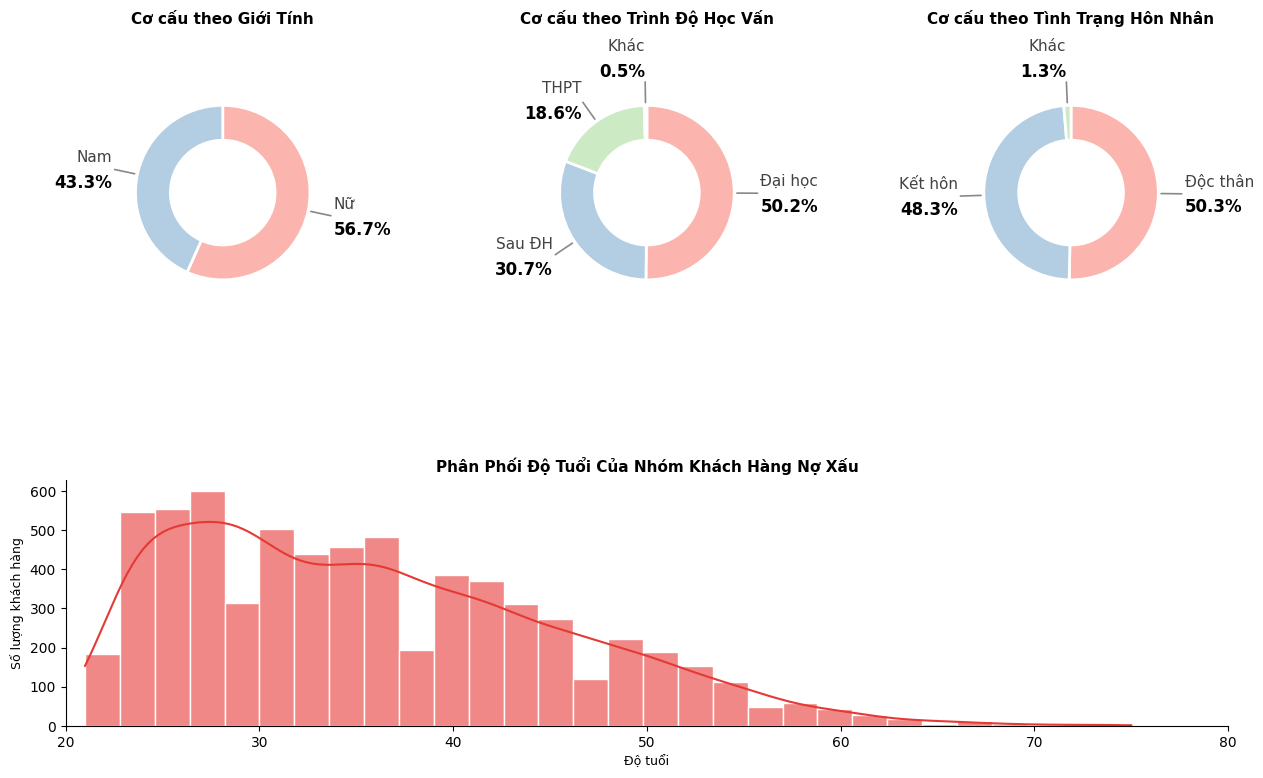

In [15]:
dict_map = {
    'SEX': {1: 'Nam', 2: 'Nữ'},
    'EDUCATION': {1: 'Sau ĐH', 2: 'Đại học', 3: 'THPT', 4: 'Khác', 5: 'Khác', 6: 'Khác', 0: 'Khác'},
    'MARRIAGE': {1: 'Kết hôn', 2: 'Độc thân', 3: 'Khác', 0: 'Khác'}
}

df_plot = df.copy()
for col in dict_map.keys():
    df_plot[col] = df_plot[col].replace(dict_map[col])

df_default = df_plot[df_plot['DEFAULT'] == 1]

fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 3, height_ratios=[1.3, 1], hspace=0.45, wspace=0.35)

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
titles = ['Giới Tính', 'Trình Độ Học Vấn', 'Tình Trạng Hôn Nhân']

for i, col in enumerate(cat_cols):
    ax = fig.add_subplot(gs[0, i])

    counts = df_default[col].value_counts()
    total = counts.sum()

    wedges, _ = ax.pie(
        counts,
        startangle=90,
        counterclock=False,
        colors=sns.color_palette("Pastel1", len(counts)),
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
    )

    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_title(f'Cơ cấu theo {titles[i]}', pad=8.5)

    for j, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))

        xy = (x, y)
        xytext = (1.3 * x, 1.3 * y)

        ax.annotate("", xy=xy, xytext=xytext,
                    arrowprops=dict(arrowstyle="-", color="#888888", linewidth=1.2))

        ha = "left" if x > 0 else "right"

        pct = (counts.values[j] / total) * 100
        label_text = counts.index[j]

        y_offset_text = 0.05
        y_offset_pct = -0.05

        if pct < 3.0 and y > 0:
            y_offset_text += 0.24
            y_offset_pct += 0.24

        ax.text(xytext[0], xytext[1] + y_offset_text, label_text,
                ha=ha, va="bottom", fontweight="normal", fontsize=11, color="#424242")
        ax.text(xytext[0], xytext[1] + y_offset_pct, f"{pct:.1f}%",
                ha=ha, va="top", fontweight="bold", fontsize=12, color="#000000")

ax_age = fig.add_subplot(gs[1, :])
sns.histplot(data=df_default, x='AGE', bins=30, kde=True, color='#E53935', ax=ax_age, alpha=0.6, edgecolor='white')
ax_age.set_title('Phân Phối Độ Tuổi Của Nhóm Khách Hàng Nợ Xấu')
ax_age.set_xlabel('Độ tuổi')
ax_age.set_ylabel('Số lượng khách hàng')
ax_age.set_xlim(20, 80)
ax_age.spines['top'].set_visible(False)
ax_age.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Phần 5: Tiến trình lịch sử thanh toán**

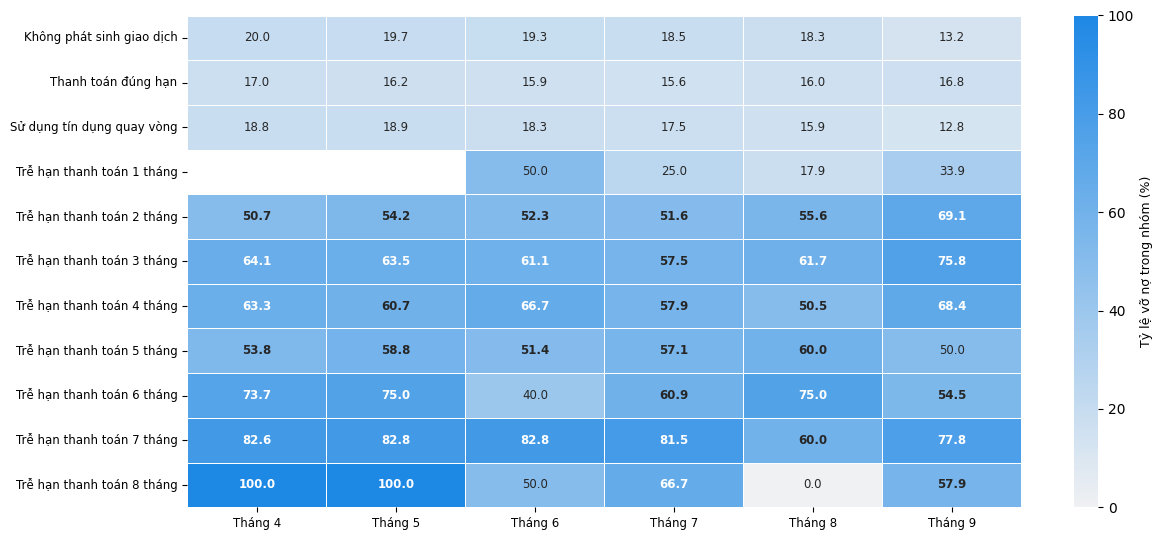

In [16]:
pay_cols_chrono = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_0']
all_y_values = pd.concat([df[col] for col in pay_cols_chrono]).unique()
y_values = sorted(all_y_values)

pay_labels_dict = {
    -2: 'Không phát sinh giao dịch',
    -1: 'Thanh toán đúng hạn',
    0: 'Sử dụng tín dụng quay vòng',
    1: 'Trễ hạn thanh toán 1 tháng',
    2: 'Trễ hạn thanh toán 2 tháng',
    3: 'Trễ hạn thanh toán 3 tháng',
    4: 'Trễ hạn thanh toán 4 tháng',
    5: 'Trễ hạn thanh toán 5 tháng',
    6: 'Trễ hạn thanh toán 6 tháng',
    7: 'Trễ hạn thanh toán 7 tháng',
    8: 'Trễ hạn thanh toán 8 tháng',
    9: 'Trễ hạn thanh toán từ 9 tháng trở lên'
}

matrix_rates = []
for y in y_values:
    row_rates = []
    for col in pay_cols_chrono:
        subset = df[df[col] == y]
        if len(subset) > 0:
            rate = (subset['DEFAULT'] == 1).mean() * 100
        else:
            rate = np.nan
        row_rates.append(rate)
    matrix_rates.append(row_rates)

df_matrix = pd.DataFrame(
    matrix_rates,
    index=[pay_labels_dict.get(y, f'Unknown ({y})') for y in y_values],
    columns=['Tháng 4', 'Tháng 5', 'Tháng 6', 'Tháng 7', 'Tháng 8', 'Tháng 9']
)

plt.figure(figsize=(12.5, 5.5))

custom_cmap = sns.light_palette(PALETTE['non_default'], as_cmap=True)

ax = sns.heatmap(
    df_matrix,
    annot=True,
    fmt=".1f",
    cmap=custom_cmap,
    linewidths=0.6,
    annot_kws={'size': 8.5},
    cbar_kws={'label': 'Tỷ lệ vỡ nợ trong nhóm (%)'}
)

for text in ax.texts:
    try:
        val = float(text.get_text())
        if val > 50.0:
            text.set_weight('bold')
    except ValueError:
        pass

plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=8.5)
plt.yticks(fontsize=8.5)

plt.tight_layout()
plt.show()